["# Policy Residual Analysis\n", "Evaluate the trained ONNX policy at every ground-truth trajectory state (zero tracking error).\n", "\n", "Compare the **nominal PD error** `joints_target[t] - joints[t]` (proportional to controller force)\n", "with the **corrected PD error** after adding the policy residual. If the policy widens the gap,\n", "it wants more force; if it shrinks it, the sim gains may be too high."]

In [1]:
import numpy as np
import yaml
import onnxruntime as ort
import matplotlib.pyplot as plt
from pathlib import Path

%matplotlib inline
plt.rcParams['figure.dpi'] = 100

joint_names = ["shoulder_pan", "shoulder_lift", "elbow", "wrist_1", "wrist_2", "wrist_3"]

In [14]:
import json


def _load_rollout(run_dir):
    """Load a recorded rollout JSON produced by scripts/rsl_rl/record.py."""
    run_dir = Path(run_dir)
    rollout_path = run_dir / "rollout" / "output.json"
    if not rollout_path.exists():
        raise FileNotFoundError(
            f"No rollout recorded for {run_dir.name}. Run:\n"
            f"  python scripts/rsl_rl/record.py --task=<TASK> "
            f"--checkpoint=<log_dir>/model_<iter>.pt\n"
            f"Expected file: {rollout_path}"
        )
    with open(rollout_path) as f:
        rollout = json.load(f)
    return rollout


def _resolve_traj_path(run_dir, traj_path):
    traj_path = Path(traj_path)
    if not traj_path.is_absolute():
        traj_path = run_dir.parent.parent.parent.parent / traj_path
    return traj_path


def analyze_residual(run_dirs, show_velocity=False):
    """Load recorded IsaacLab rollouts and compare per-joint PD error signals.

    Each run_dir must have a recorded rollout at <run_dir>/rollout/output.json
    (produced by scripts/rsl_rl/record.py). All runs must share the same trajectory.
    """
    if isinstance(run_dirs, (str, Path)):
        run_dirs = [run_dirs]
    run_dirs = [Path(p) for p in run_dirs]

    rollouts = [_load_rollout(rd) for rd in run_dirs]

    traj_paths_used = {r["trajectory_path"] for r in rollouts}
    if len(traj_paths_used) > 1:
        raise ValueError(
            "All runs must share the same trajectory_path. Got:\n  " +
            "\n  ".join(sorted(traj_paths_used))
        )
    traj_path = _resolve_traj_path(run_dirs[0], next(iter(traj_paths_used)))

    print(traj_path)
    traj = np.load(traj_path)

    dual_arm = rollouts[0]["dual_arm"]
    if dual_arm:
        joints_ref = np.concatenate([traj["joints_l"], traj["joints_r"]], axis=-1)
        joint_vel_ref = np.concatenate([traj["joint_vel_l"], traj["joint_vel_r"]], axis=-1)
        joints_target_ref = np.concatenate([traj["joints_target_l"], traj["joints_target_r"]], axis=-1)
        n_joints = 12
        names = [f"L {n}" for n in joint_names] + [f"R {n}" for n in joint_names]
    else:
        joints_ref = traj["joints"]
        joint_vel_ref = traj["joint_vel"]
        joints_target_ref = traj["joints_target"]
        n_joints = 6
        names = joint_names

    # Per-run configs
    env_cfgs = []
    for run_dir in run_dirs:
        with open(run_dir / "params" / "env.yaml") as f:
            env_cfgs.append(yaml.unsafe_load(f))

    per_run = []
    for run_dir, rollout, env_cfg in zip(run_dirs, rollouts, env_cfgs):
        kp = env_cfg.get("kp")
        kd = env_cfg.get("kd")

        print(rollout.keys())

        joint_pos = np.asarray(rollout["joint_positions"])  # (N+1, n_joints)
        joint_targets_cmd = np.asarray(rollout["joint_targets"])  # (N, n_joints)
        joint_torques = np.asarray(rollout["joint_torques"])  # (N, n_joints)

        # Align lengths: joint_pos starts before the first action
        N = len(joint_targets_cmd)
        joint_pos = joint_pos[:N]

        # Reference truncated/aligned to rollout length (rollout may end early on termination)
        nominal_pd_error = (joints_target_ref[:N] - joint_pos)
        # Actual PD error the controller saw during the rollout
        corrected_pd_error = joint_targets_cmd - joint_pos

        per_run.append({
            "label": f"kp={kp}, kd={kd}",
            "run_name": run_dir.name,
            "joint_pos": joint_pos,
            "joint_targets_cmd": joint_targets_cmd,
            "joint_torques": joint_torques,
            "corrected": corrected_pd_error,
            "action_mode": rollout.get("action_mode"),
            "obs_history_steps": rollout.get("obs_history_steps"),
            "action_scale": rollout.get("action_scale"),
            "kp": kp,
            "kd": kd,
            "N": N,
        })
        print(f"{run_dir.name}: {N} steps, action_scale={rollout.get('action_scale')}, "
              f"action_mode={rollout.get('action_mode')}, "
              f"obs_history={rollout.get('obs_history_steps')}, kp={kp}, kd={kd}")
    print(f"Trajectory: {traj_path.name}")

    # Truncate nominal error to the shortest rollout
    min_N = min(r["N"] for r in per_run)
    nominal_pd_error = (joints_target_ref - joints_ref)[:min_N]
    time = np.arange(min_N) * 0.02

    colors = plt.get_cmap("tab10").colors
    n_cols = 2
    n_rows = (n_joints + n_cols - 1) // n_cols

    # --- PD error: nominal vs corrected (one line per run) ---
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 10), sharex=True)
    axes_flat = axes.flatten() if n_rows > 1 else [axes] if n_cols == 1 else list(axes)
    for i in range(n_joints):
        ax = axes_flat[i]
        name = names[i]
        ax.plot(time, nominal_pd_error[:min_N, i], color='gray', alpha=0.7,
                label='nominal (joints_target - joints_pos)')
        for k, run in enumerate(per_run):
            ax.plot(time, run["corrected"][:min_N, i], color=colors[k % len(colors)],
                    alpha=0.85, label=f'rollout: {run["label"]}')
        ax.axhline(0, color='k', linewidth=0.5)
        ax.set_title(f"{name}", fontsize=10)
        ax.set_ylabel('PD error (rad)')
        ax.grid(True, alpha=0.3)

        lines_l, labels_l = ax.get_legend_handles_labels()

        if show_velocity:
            ax_v = ax.twinx()
            ax_v.plot(time, joint_vel_ref[:min_N, i], color='tab:green', alpha=0.6, linewidth=1,
                      label='joint vel')
            ax_v.axhline(0, color='tab:green', linewidth=0.3, alpha=0.3)
            ax_v.set_ylabel('joint vel (rad/s)', color='tab:green')
            ax_v.tick_params(axis='y', labelcolor='tab:green')
            if i == 0:
                lines_r, labels_r = ax_v.get_legend_handles_labels()
                lines_l += lines_r
                labels_l += labels_r

        if i == 0:
            ax.legend(lines_l, labels_l, fontsize=7, loc='best')
    for i in range(n_joints, len(axes_flat)):
        axes_flat[i].set_visible(False)
    axes_flat[-n_cols].set_xlabel('time (s)')
    if n_cols > 1:
        axes_flat[-1].set_xlabel('time (s)')
    title = per_run[0]["run_name"] if len(run_dirs) == 1 else f"{len(run_dirs)} runs"
    fig.suptitle(f"PD error signal: nominal vs policy-corrected (sim rollout) — {title}", fontsize=11)
    plt.tight_layout()

    return per_run, nominal_pd_error

In [15]:
from scipy.interpolate import interp1d

def _upsample_linear(x, k):
    N = x.shape[0]
    t_old = np.arange(N)
    t_new = np.linspace(0, N - 1, k * (N - 1) + 1)
    return interp1d(t_old, x, axis=0, kind="linear")(t_new)


def compare_upsampling(run_dir, alpha=0.05, ds=5, start_i=0):
    """Load the recorded IsaacLab rollout and compare linear vs IIR upsampling
    of the commanded joint targets to 500 Hz."""
    run_dir = Path(run_dir)
    rollout = _load_rollout(run_dir)
    joint_targets = np.asarray(rollout["joint_targets"])  # (N, n_joints)
    joint_pos_start = np.asarray(rollout["joint_positions"][0])  # initial joint pos

    if rollout["dual_arm"]:
        n_joints = 12
        names = [f"L {n}" for n in joint_names] + [f"R {n}" for n in joint_names]
    else:
        n_joints = 6
        names = joint_names

    # Prepend initial joint pos so first segment goes from start state to first commanded target
    commanded = np.vstack([joint_pos_start[None, :], joint_targets])  # (N+1, n_joints)
    commanded = commanded[start_i:]

    decimation = 10  # 50 Hz policy -> 500 Hz control
    traj_x = np.arange(len(commanded)) * decimation
    ref_steps = np.arange(traj_x[-1] + 1)

    linear = _upsample_linear(commanded, decimation)

    iir = np.empty_like(linear)
    iir[0] = commanded[0]
    one_minus_alpha = 1.0 - alpha
    for i, target in enumerate(commanded[:-1]):
        for j in range(decimation):
            n = i * decimation + j
            iir[n + 1] = one_minus_alpha * iir[n] + alpha * target

    n_cols = 2
    n_rows = (n_joints + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 10), sharex=True)
    axes_flat = axes.flatten()
    for i in range(n_joints):
        ax = axes_flat[i]
        ax.plot(traj_x, commanded[:, i], 'o', markersize=2.5, color='k',
                alpha=0.5, label='policy targets (50 Hz)')
        ax.plot(ref_steps[::ds], linear[::ds, i], label='linear interp',
                color='tab:green', alpha=0.85)
        ax.plot(ref_steps[::ds], iir[::ds, i], label=f'IIR (\u03b1={alpha})',
                color='tab:red', alpha=0.85)
        ax.set_title(names[i], fontsize=10)
        ax.set_ylabel('position (rad)')
        ax.grid(True, alpha=0.3)
        if i == 0:
            ax.legend(fontsize=8, loc='best')
    for i in range(n_joints, len(axes_flat)):
        axes_flat[i].set_visible(False)
    axes_flat[-n_cols].set_xlabel('step (500 Hz)')
    if n_cols > 1:
        axes_flat[-1].set_xlabel('step (500 Hz)')
    fig.suptitle(f"Rollout targets: linear vs IIR — {run_dir.name}", fontsize=11)
    plt.tight_layout()

In [16]:
def plot_rewards(run_dirs, keys=None):
    """Plot per-step total reward and any extras["log"] keys from recorded rollouts.

    Args:
        run_dirs: single run directory or list of run directories (must have rollouts).
        keys: list of extras["log"] keys to plot, one subplot each. If None, plots
            only the total reward. Pass "all" to plot every key found in the rollout.
    """
    if isinstance(run_dirs, (str, Path)):
        run_dirs = [run_dirs]
    run_dirs = [Path(p) for p in run_dirs]

    rollouts_info = []
    for rd in run_dirs:
        rollout = _load_rollout(rd)
        with open(rd / "params" / "env.yaml") as f:
            cfg = yaml.unsafe_load(f)
        kp = cfg.get("kp")
        kd = cfg.get("kd")
        rollouts_info.append({
            "label": f"kp={kp}, kd={kd}",
            "run_name": rd.name,
            "rewards": np.asarray(rollout.get("rewards", [])),
            "extras": rollout.get("extras", []),
        })

    available_keys = set()
    for r in rollouts_info:
        for entry in r["extras"]:
            available_keys.update(entry.keys())

    if keys == "all":
        keys = sorted(available_keys)
    elif keys is None:
        keys = []

    n_panels = 1 + len(keys)
    fig, axes = plt.subplots(n_panels, 1, figsize=(12, 2.5 * n_panels), sharex=True)
    if n_panels == 1:
        axes = [axes]

    colors = plt.get_cmap("tab10").colors

    # Total reward
    ax = axes[0]
    for k, r in enumerate(rollouts_info):
        if len(r["rewards"]) > 0:
            ax.plot(np.arange(len(r["rewards"])) * 0.02, r["rewards"],
                    color=colors[k % len(colors)], alpha=0.85, label=r["label"])
    ax.set_ylabel("total reward")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, loc='best')

    # Extras
    for idx, key in enumerate(keys, start=1):
        ax = axes[idx]
        for k, r in enumerate(rollouts_info):
            values = np.array([entry.get(key, np.nan) for entry in r["extras"]])
            ax.plot(np.arange(len(values)) * 0.02, values,
                    color=colors[k % len(colors)], alpha=0.85, label=r["label"])
        ax.set_ylabel(key, fontsize=9)
        ax.grid(True, alpha=0.3)

    axes[-1].set_xlabel("time (s)")
    title = rollouts_info[0]["run_name"] if len(rollouts_info) == 1 else f"{len(rollouts_info)} runs"
    fig.suptitle(f"Rollout rewards — {title}", fontsize=11)
    plt.tight_layout()

    print(f"Available extras keys: {sorted(available_keys)}")

../reference_trajectories/box_rotate_ur5e/traj_full_refined_20260417_134041_cubic.npz
dict_keys(['joint_targets', 'joint_positions', 'joint_torques', 'rewards', 'extras', 'trajectory_path', 'action_scale', 'action_mode', 'obs_history_steps', 'dual_arm', 'arm_pose'])
2026-04-23_15-05-14: 324 steps, action_scale=0.05, action_mode=D, obs_history=3, kp=150.0, kd=22.5
Trajectory: traj_full_refined_20260417_134041_cubic.npz


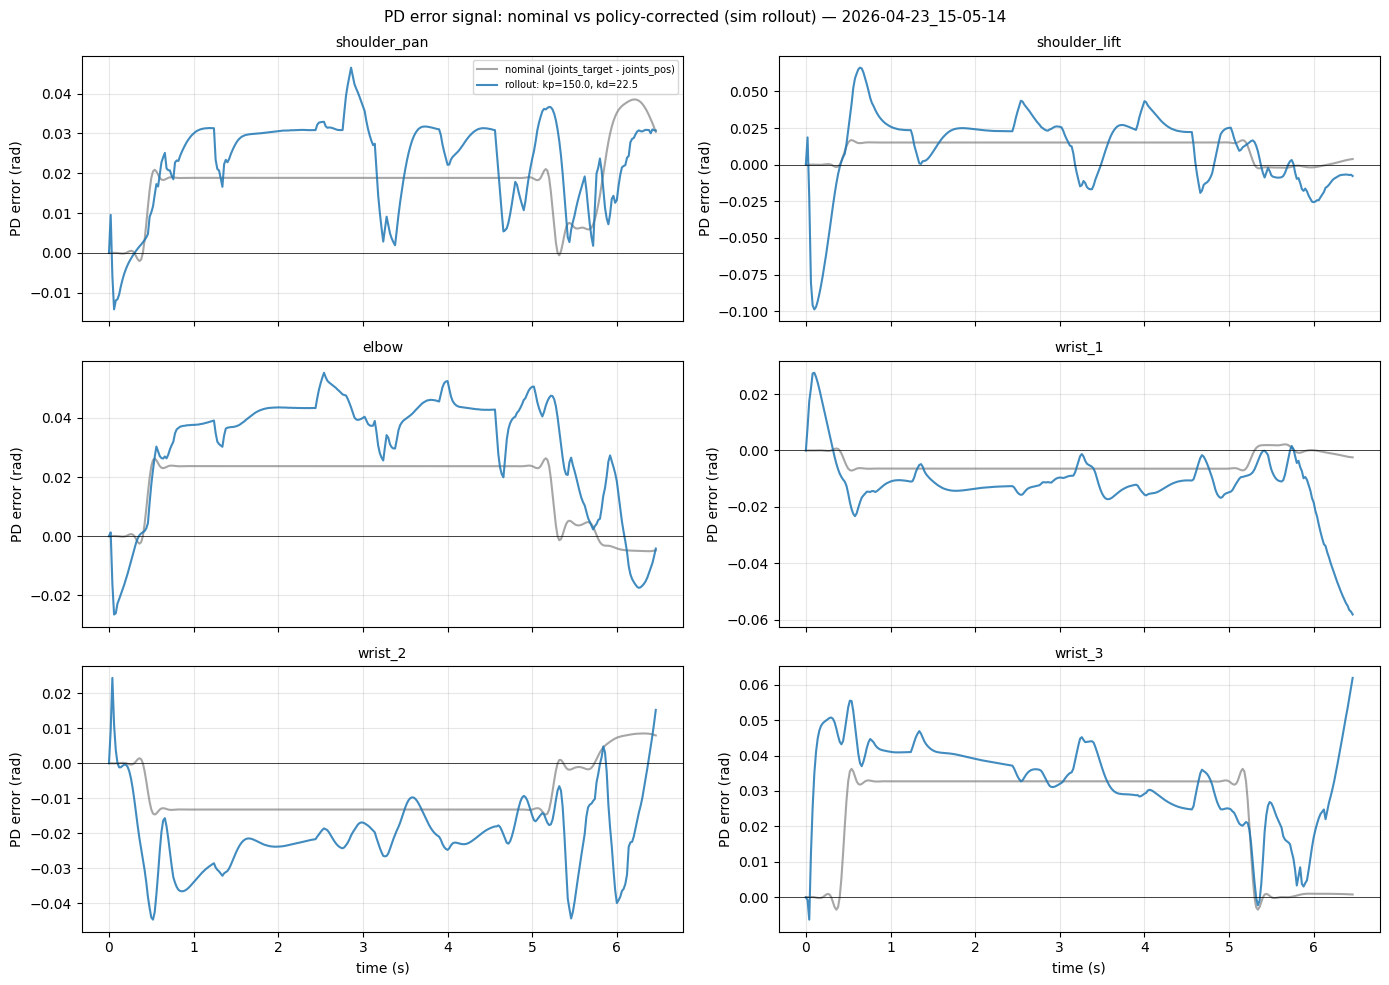

In [18]:
r = analyze_residual(
    [
        "../logs/rsl_rl/boxpush/2026-04-23_15-05-14"
    ],
    show_velocity=False
)

Available extras keys: ['Curriculum/alpha', 'Curriculum/policy_reg_scale', 'Error/EE_pos_error', 'Error/obj_pos_error', 'Error/obj_quat_error', 'Phase/frac_deep_paused', 'Phase/frac_slowed', 'Phase/max_cumulative_slowdown', 'Phase/mean_cumulative_slowdown', 'Phase/mean_dphase', 'Phase/mean_phase_norm', 'Phase/min_dphase', 'PhaseResample/max_failure_rate', 'PhaseResample/mean_failure_rate', 'PhaseResample/min_failure_rate', 'PhaseResample/sample_entropy', 'Rewards/completion_bonus', 'Rewards/completion_fraction', 'Rewards_regularization/action_norm', 'Rewards_regularization/action_rate', 'Rewards_regularization/flange_forearm_distance', 'Rewards_regularization/illegal_contact', 'Rewards_regularization/illegal_proximity', 'Rewards_regularization/joint_acceleration', 'Rewards_regularization/joint_limit', 'Rewards_regularization/torque', 'Rewards_regularization/total', 'Rewards_regularization/total_slowdown', 'Rewards_task/obj_pos', 'Rewards_task/obj_quat', 'Rewards_task/total', 'Rewards_t

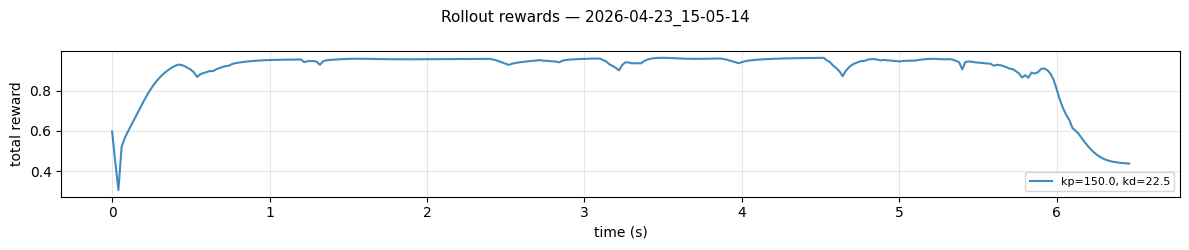

In [27]:
plot_rewards("../logs/rsl_rl/boxpush/2026-04-23_15-05-14")

rd = Path("../logs/rsl_rl/boxpush/2026-04-23_15-05-14")
rollout = _load_rollout(rd)
with open(rd / "params" / "env.yaml") as f:
    cfg = yaml.unsafe_load(f)
kp = cfg.get("kp")
kd = cfg.get("kd")

extras = rollout.get("extras", [])

print(extras[0].keys())